# Exam cheating — EDA: original vs preprocessed

**Original:** raw files under `ExamCheatingDataset/`.  
**Preprocessed:** outputs from `image_preprocess_opencv.py --batch -o …` (PNGs under `ExamCheatingDataset_preprocessed/` or your chosen folder).

Keeps compatible columns so you can compare resolutions, sizes, aspect ratios, and sampled intensity stats.
- Preprocessed images should be fixed size (299×299) grayscale PNGs unless you changed defaults.

In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

NOTEBOOK_DIR = Path.cwd()

_ORIG_CANDS = [
    NOTEBOOK_DIR / "ExamCheatingDataset",
    NOTEBOOK_DIR.parent / "ExamCheatingDataset",
]
_PROC_CANDS = [
    NOTEBOOK_DIR / "ExamCheatingDataset_preprocessed",
    NOTEBOOK_DIR.parent / "ExamCheatingDataset_preprocessed",
]


def resolve_dataset_dir(candidates, label):
    for p in candidates:
        if (p / "train").is_dir() and (p / "test" / "images").is_dir():
            return p.resolve()
    raise FileNotFoundError(
        f"{label} not found. Checked: {[str(c.resolve()) if c.exists() else str(c) for c in candidates]}. "
        f"Adjust candidates or cd next to ML KIngs."
    )


def resolve_preprocessed_dir(candidates, label):
    for p in candidates:
        if not (p / "train").is_dir():
            continue
        train_has_class = any(
            d.is_dir()
            for d in (p / "train").iterdir()
            if d.name not in {".DS_Store"}
        )
        if train_has_class:
            return p.resolve()
    raise FileNotFoundError(
        f"{label} not found. Checked standard locations next to this notebook."
    )


ORIGINAL_DIR = resolve_dataset_dir(_ORIG_CANDS, "ExamCheatingDataset")
# Preprocessed: expects train/<class>/ …; test/images/ optional
try:
    PREPROCESSED_DIR = resolve_preprocessed_dir(_PROC_CANDS, "preprocessed folder")
except FileNotFoundError as e:
    PREPROCESSED_DIR = None
    print("WARN:", e)
    print("Run batch first, e.g.:")
    print("  python image_preprocess_opencv.py --batch -o ExamCheatingDataset_preprocessed")

print("Original dir:       ", ORIGINAL_DIR)
print("Preprocessed dir:   ", PREPROCESSED_DIR)

Original dir:        /Users/dipesh/Desktop/ML KIngs/ExamCheatingDataset
Preprocessed dir:    /Users/dipesh/Desktop/ML KIngs/ExamCheatingDataset_preprocessed


In [2]:
_IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif"}

TRAIN_O = ORIGINAL_DIR / "train"
TEST_O = ORIGINAL_DIR / "test" / "images"

classes = sorted([d.name for d in TRAIN_O.iterdir() if d.is_dir()])
test_original_paths = sorted(
    p for p in TEST_O.iterdir() if p.is_file() and p.suffix.lower() in _IMG_EXT
) if TEST_O.is_dir() else []


def pil_stats(path):
    from PIL import Image

    with Image.open(path) as img:
        w, h = img.size
        mode = img.mode
        arr = np.array(img.convert("L"))
    return dict(
        width=w,
        height=h,
        aspect_ratio=round(w / h, 4) if h else None,
        mode=mode,
        file_size_kb=round(path.stat().st_size / 1024, 2),
        mean_gray=float(arr.mean()),
        std_gray=float(arr.std()),
    )


records_o = []

for cls in classes:
    for img_path in sorted((TRAIN_O / cls).iterdir()):
        if not img_path.is_file() or img_path.suffix.lower() not in _IMG_EXT:
            continue
        try:
            st = pil_stats(img_path)
            records_o.append(
                dict(
                    version="original",
                    split="train",
                    label=cls,
                    rel_path=str(img_path.relative_to(ORIGINAL_DIR)),
                    stem=img_path.stem,
                    path=str(img_path),
                    filename=img_path.name,
                    **st,
                )
            )
        except Exception as e:
            print(f"skip train {img_path}: {e}")

for img_path in test_original_paths:
    try:
        st = pil_stats(img_path)
        records_o.append(
            dict(
                version="original",
                split="test",
                label=None,
                rel_path=str(img_path.relative_to(ORIGINAL_DIR)),
                stem=img_path.stem,
                path=str(img_path),
                filename=img_path.name,
                **st,
            )
        )
    except Exception as e:
        print(f"skip test {img_path}: {e}")

df_original = pd.DataFrame(records_o)
print("original rows", len(df_original))
df_original.head()

original rows 2058


,version,split,label,rel_path,stem,path,filename,width,height,aspect_ratio,mode,file_size_kb,mean_gray,std_gray
0,original,train,cheating,train/cheating/1_JPG_jpg.rf.074a57a8c4a4f3881b...,1_JPG_jpg.rf.074a57a8c4a4f3881bf09845fe70e5a8,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,1_JPG_jpg.rf.074a57a8c4a4f3881bf09845fe70e5a8.jpg,640,640,1.0,RGB,33.56,57.010442,51.431274
1,original,train,cheating,train/cheating/33_jpg.rf.d2db6a53524e1181e5dc7...,33_jpg.rf.d2db6a53524e1181e5dc7b5f0d2af217,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,33_jpg.rf.d2db6a53524e1181e5dc7b5f0d2af217.jpg,640,640,1.0,RGB,40.73,159.211941,68.406941
2,original,train,cheating,train/cheating/34_jpg.rf.271a5c5a50376f1769b7d...,34_jpg.rf.271a5c5a50376f1769b7d5f67b3248bf,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,34_jpg.rf.271a5c5a50376f1769b7d5f67b3248bf.jpg,640,640,1.0,RGB,42.00,162.877998,58.614053
3,original,train,cheating,train/cheating/36_jpg.rf.f160f5c037027dbf5cfd6...,36_jpg.rf.f160f5c037027dbf5cfd6a11d4481b93,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,36_jpg.rf.f160f5c037027dbf5cfd6a11d4481b93.jpg,640,640,1.0,RGB,49.29,138.502322,63.987289
4,original,train,cheating,train/cheating/38_jpg.rf.bddd6aa9d4c45ec4703e2...,38_jpg.rf.bddd6aa9d4c45ec4703e22cede4913d2,/Users/dipesh/Desktop/ML KIngs/ExamCheatingDat...,38_jpg.rf.bddd6aa9d4c45ec4703e22cede4913d2.jpg,640,640,1.0,RGB,50.48,156.626897,71.445664


In [3]:
records_p = []

if PREPROCESSED_DIR is None:
    df_pre = pd.DataFrame()
    print("No preprocessed directory — skipping load.")
else:
    TRAIN_P = PREPROCESSED_DIR / "train"
    TEST_P = PREPROCESSED_DIR / "test" / "images"

    assert TRAIN_P.is_dir(), PREPROCESSED_DIR

    for cls in classes:
        d = TRAIN_P / cls
        if not d.is_dir():
            continue
        for img_path in sorted(d.iterdir()):
            if not img_path.is_file() or img_path.suffix.lower() not in {".png", ".jpg"}:
                continue
            try:
                st = pil_stats(img_path)
                records_p.append(
                    dict(
                        version="preprocessed",
                        split="train",
                        label=cls,
                        rel_path=str(img_path.relative_to(PREPROCESSED_DIR)),
                        stem=img_path.stem,
                        path=str(img_path),
                        filename=img_path.name,
                        **st,
                    )
                )
            except Exception as e:
                print(f"skip train {img_path}: {e}")

    if TEST_P.is_dir():
        for img_path in sorted(TEST_P.iterdir()):
            if not img_path.is_file():
                continue
            try:
                st = pil_stats(img_path)
                records_p.append(
                    dict(
                        version="preprocessed",
                        split="test",
                        label=None,
                        rel_path=str(img_path.relative_to(PREPROCESSED_DIR)),
                        stem=img_path.stem,
                        path=str(img_path),
                        filename=img_path.name,
                        **st,
                    )
                )
            except Exception as e:
                print(f"skip test {img_path}: {e}")

    df_pre = pd.DataFrame(records_p)
    print("preprocessed rows", len(df_pre))
    df_pre.head()

preprocessed rows 2058


## Numeric summary comparison

In [4]:
if len(df_pre) == 0:
    print("No preprocessed dataframe — comparisons below will be originals only.")

num_cols = ["width", "height", "aspect_ratio", "file_size_kb", "mean_gray", "std_gray"]

for name, dfx in [("ORIGINAL", df_original), ("PREPROCESSED", df_pre)]:
    print("=" * 50, name, "=" * 50)
    if len(dfx) == 0:
        print("(empty)")
        continue
    print(dfx[num_cols].describe().round(2).to_string())
    print()

================================================== ORIGINAL ==================================================
         width   height  aspect_ratio  file_size_kb  mean_gray  std_gray
count  2058.00  2058.00       2058.00       2058.00    2058.00   2058.00
mean    329.32   308.00          1.07         28.77     127.46     60.66
std     134.08   126.32          0.23         72.98      22.52      9.89
min      72.00    68.00          0.37          2.74      28.24     21.30
25%     239.25   243.00          1.00         16.25     114.33     55.53
50%     323.00   294.00          1.00         21.28     128.06     59.30
75%     416.00   416.00          1.18         26.66     135.61     66.24
max    1047.00  1500.00          1.91       1613.54     239.69    104.37

================================================== PREPROCESSED ==================================================
        width  height  aspect_ratio  file_size_kb  mean_gray  std_gray
count  2058.0  2058.0        2058.0       205

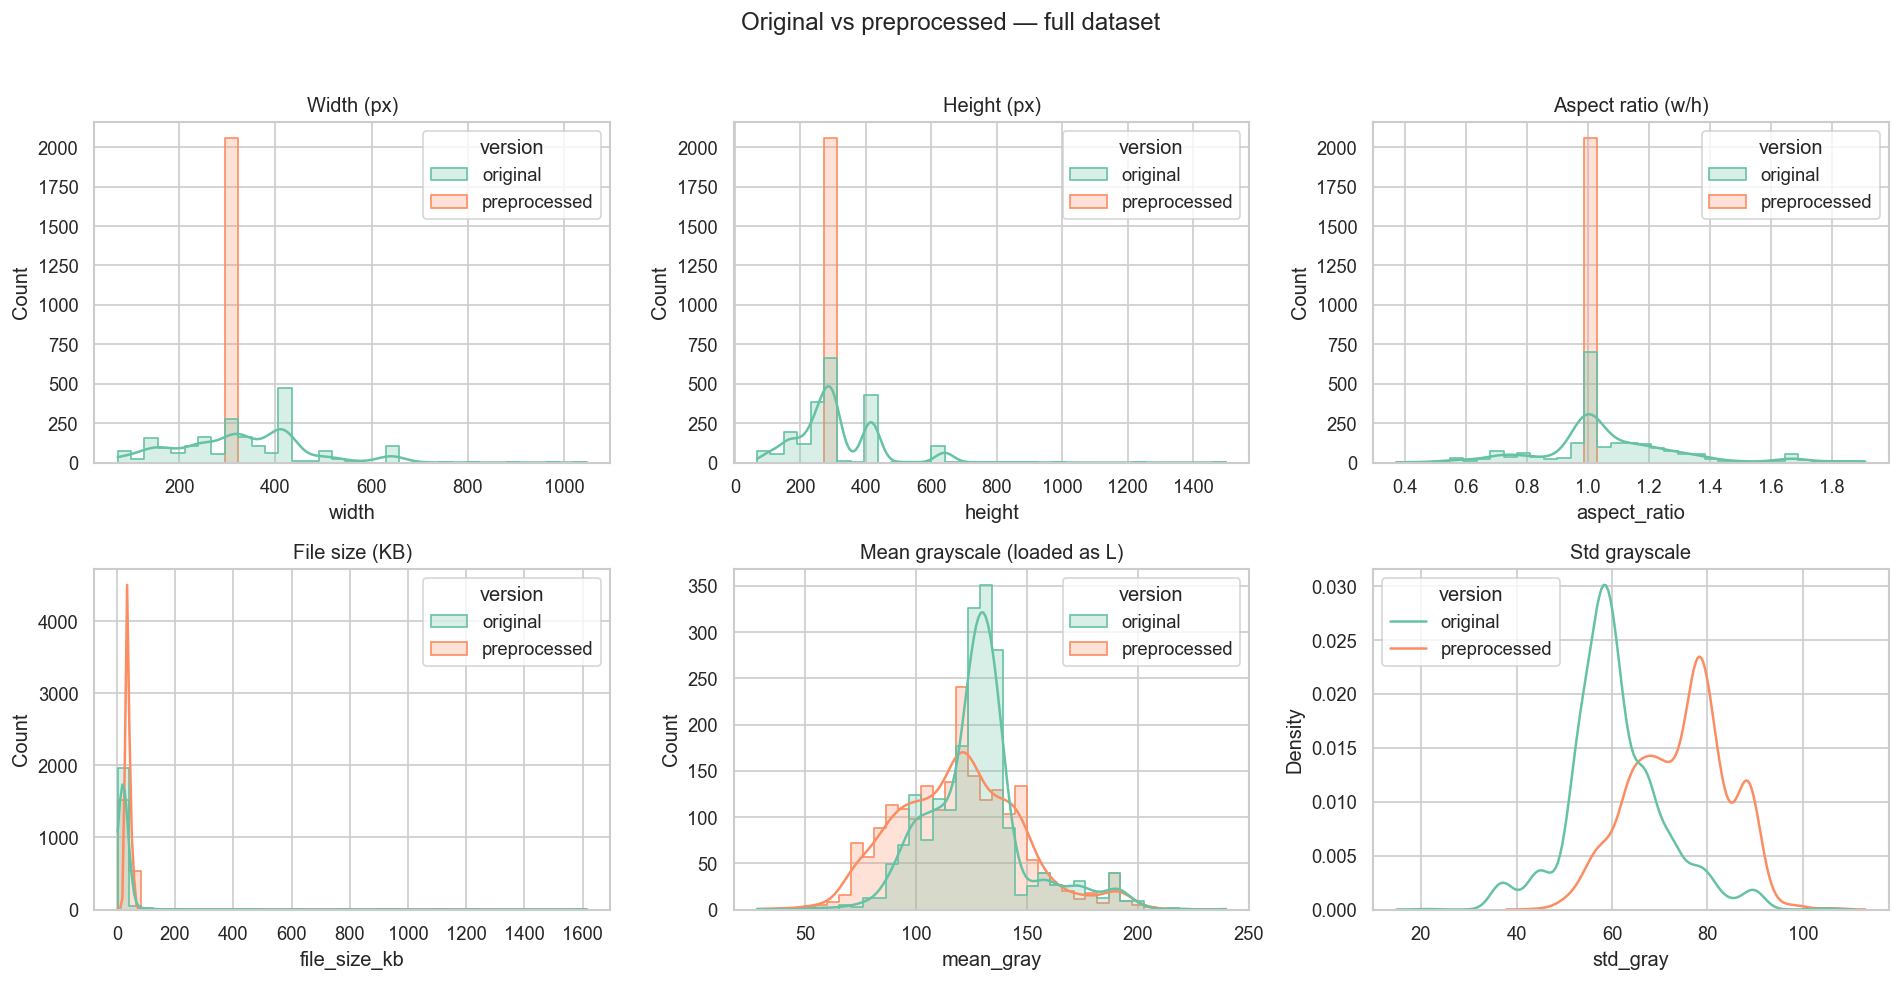

In [5]:
if len(df_pre) > 0:
    both = pd.concat([df_original, df_pre], ignore_index=True)

    fig, axes = plt.subplots(2, 3, figsize=(16, 8))

    sns.histplot(data=both, x="width", hue="version", bins=35, kde=True, ax=axes[0, 0], element="step")
    axes[0, 0].set_title("Width (px)")

    sns.histplot(data=both, x="height", hue="version", bins=35, kde=True, ax=axes[0, 1], element="step")
    axes[0, 1].set_title("Height (px)")

    sns.histplot(data=both, x="aspect_ratio", hue="version", bins=35, kde=True, ax=axes[0, 2], element="step")
    axes[0, 2].set_title("Aspect ratio (w/h)")

    sns.histplot(data=both, x="file_size_kb", hue="version", bins=40, kde=True, ax=axes[1, 0], element="step")
    axes[1, 0].set_title("File size (KB)")

    sns.histplot(data=both, x="mean_gray", hue="version", bins=40, kde=True, ax=axes[1, 1], element="step")
    axes[1, 1].set_title("Mean grayscale (loaded as L)")

    sns.kdeplot(data=both, x="std_gray", hue="version", ax=axes[1, 2], fill=False)
    axes[1, 2].set_title("Std grayscale")

    plt.suptitle("Original vs preprocessed — full dataset", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Showing originals only …")
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    sns.histplot(df_original["width"], bins=35, kde=True, ax=axes[0])
    axes[0].set_title("Width")
    sns.histplot(df_original["height"], bins=35, kde=True, ax=axes[1])
    axes[1].set_title("Height")
    sns.histplot(df_original["aspect_ratio"], bins=35, kde=True, ax=axes[2])
    axes[2].set_title("Aspect ratio")
    sns.histplot(df_original["file_size_kb"], bins=40, kde=True, ax=axes[3])
    axes[3].set_title("File size KB")
    plt.tight_layout()
    plt.show()

/var/folders/6b/2xdghg1d1pbdb4bm239g47vh0000gn/T/ipykernel_12658/908824076.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right")


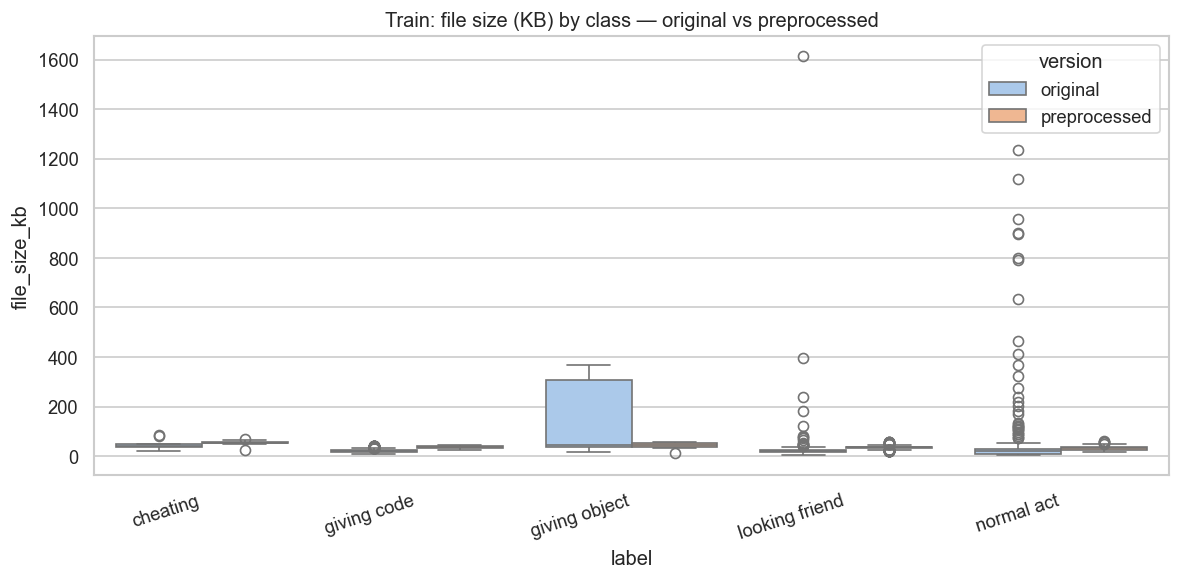

In [6]:
if len(df_pre) > 0:
    o_train = df_original["split"] == "train"
    p_train = df_pre["split"] == "train"
    subset = pd.concat(
        [
            df_original.loc[o_train].assign(version="original"),
            df_pre.loc[p_train].assign(version="preprocessed"),
        ],
        ignore_index=True,
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=subset, x="label", y="file_size_kb", hue="version", palette="pastel")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=18, ha="right")
    ax.set_title("Train: file size (KB) by class — original vs preprocessed")
    plt.tight_layout()
    plt.show()

## Sample pairs (same filename stem)

Stem matches: 2053; showing first 4 random picks


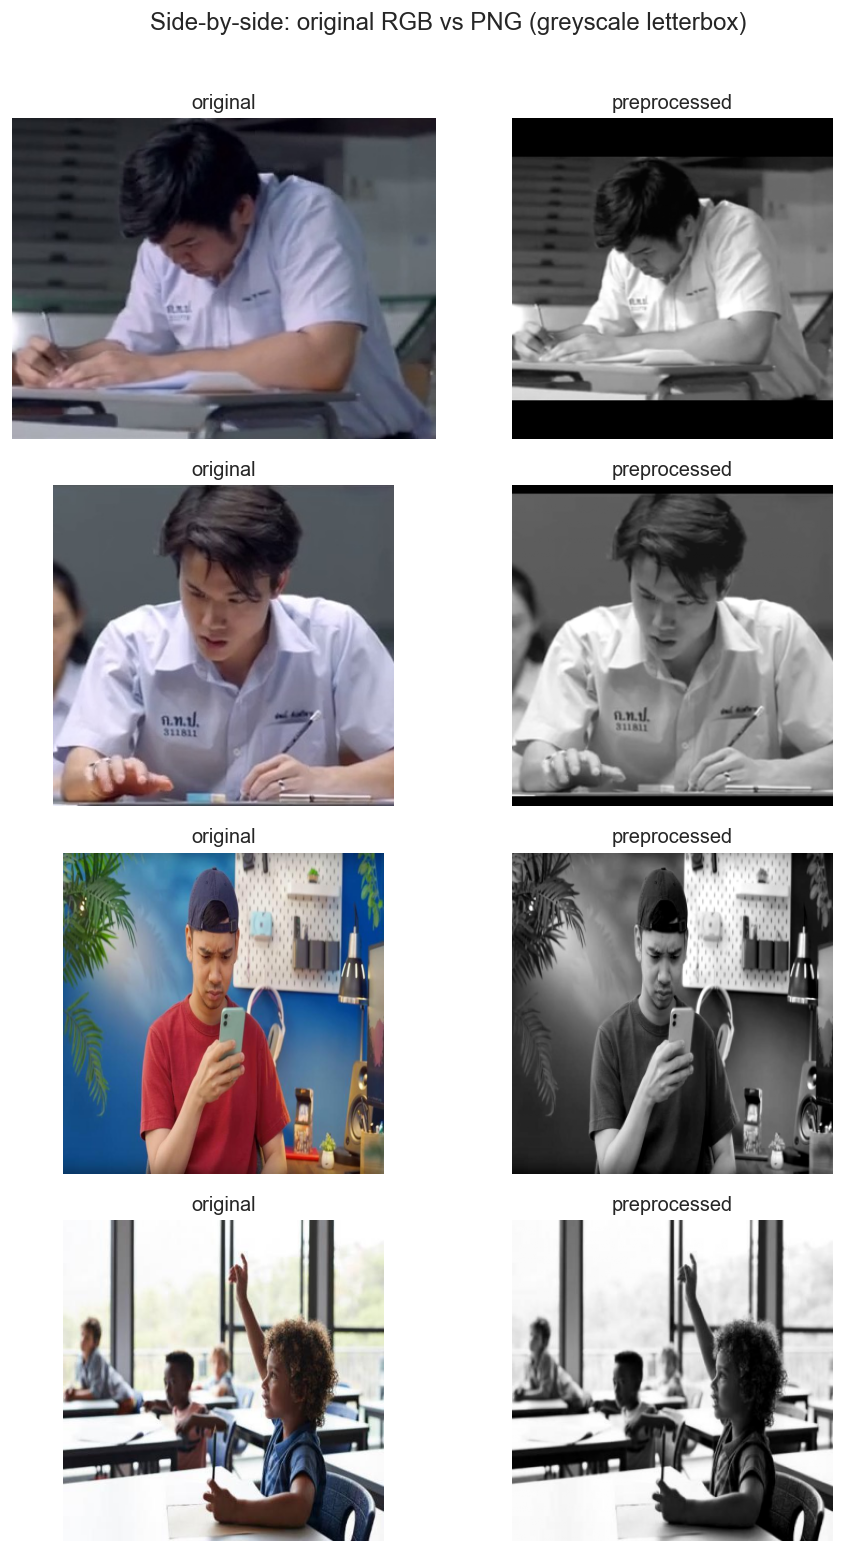

In [8]:
if PREPROCESSED_DIR is None or len(df_pre) == 0:
    print("Need batch output folder to visualize pairs.")
else:
    by_stem = df_original.set_index("stem")
    by_stem_pre = df_pre.set_index("stem")
    shared = sorted(set(by_stem.index).intersection(by_stem_pre.index))
    random.shuffle(shared)
    n_show = min(4, len(shared))
    print(f"Stem matches: {len(shared)}; showing first {n_show} random picks")

    if n_show == 0:
        print("No overlapping stems — check preprocessed stems vs originals.")
    else:
        fig, axes = plt.subplots(n_show, 2, figsize=(8, 3.2 * n_show))
        if n_show == 1:
            axes = np.array([[axes]])
        # shared shuffled picks
        picks = shared[: n_show]

        def show_pair(ax_pair, stem):
            ro = by_stem.loc[stem]
            rp = by_stem_pre.loc[stem]
            if isinstance(ro, pd.Series):
                po, pp = Path(ro["path"]), Path(rp["path"])
            else:
                po = Path(ro.iloc[0]["path"])
                pp = Path(rp.iloc[0]["path"])
            ax_pair[0].imshow(mpimg.imread(po))
            ax_pair[0].set_title("original")
            ax_pair[0].axis("off")
            ax_pair[1].imshow(mpimg.imread(pp), cmap="gray")
            ax_pair[1].set_title("preprocessed")
            ax_pair[1].axis("off")

        for idx, stem in enumerate(picks):
            show_pair(axes[idx], stem)
            axes[idx][0].set_ylabel(stem[:30] + ("…" if len(stem) > 30 else ""), fontsize=8)
        plt.suptitle("Side-by-side: original RGB vs PNG (greyscale letterbox)", y=1.01)
        plt.tight_layout()
        plt.show()

### Short textual summary

- Expect preprocessed width/height to spike at pipeline `target_hw` (default 299).  
- `mean_gray` / `std_gray` are comparable in spirit across versions (computed on Pillow `L`).  
- Re-run batch if counts differ (`original rows` vs `preprocessed rows`).

In [9]:
print("ORIGINAL")
print(df_original.groupby("split").size())
print(df_original["mode"].value_counts())

if len(df_pre) > 0:
    print("\nPREPROCESSED")
    print(df_pre.groupby("split").size())
    print(df_pre["mode"].value_counts())
    oo = df_original.groupby("stem").size()
    pp = df_pre.groupby("stem").size()
    unmatched_o = oo.index.difference(pp.index)
    unmatched_p = pp.index.difference(oo.index)
    print(f"\nStems only in original: {len(unmatched_o)}  | only in preprocessed: {len(unmatched_p)}")

ORIGINAL
split
test      496
train    1562
dtype: int64
mode
RGB     2004
RGBA      54
Name: count, dtype: int64

PREPROCESSED
split
test      496
train    1562
dtype: int64
mode
L    2058
Name: count, dtype: int64

Stems only in original: 0  | only in preprocessed: 0
